In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ising

from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

## Single run

In [2]:
n_qubits = 3
magnetization = ising.gen_magnetization_op(n_qubits)

field_str = 0.433
hamiltonian = ising.gen_hamiltonian_op(field=field_str, coupling=1.0, n_qubits=n_qubits)
print(hamiltonian)

eigenvalues, eigenvectors = np.linalg.eigh(np.array(hamiltonian))
e_gs = min(eigenvalues)
print("The ground state energy is ", e_gs)

SparsePauliOp(['XII', 'IXI', 'IIX', 'ZZI', 'IZZ', 'ZIZ'],
              coeffs=[-0.433+0.j, -0.433+0.j, -0.433+0.j, -1.   +0.j, -1.   +0.j, -1.   +0.j])
The ground state energy is  -3.1702265252407362


This circuit has  18 parameters


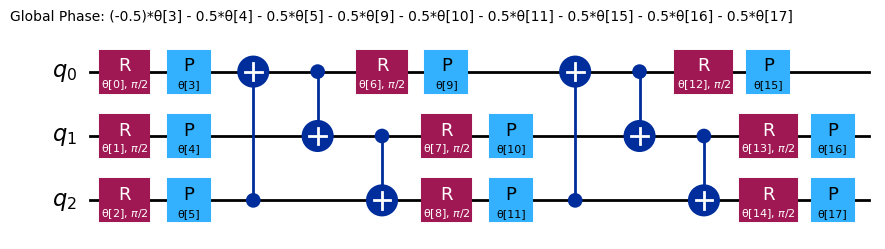

In [3]:
ansatz = efficient_su2(
    hamiltonian.num_qubits, entanglement="circular", reps=2
)

print("This circuit has ", ansatz.num_parameters, "parameters")
ansatz.decompose().draw("mpl")

In [4]:
def compute_expectation(params, ansatz, operator):
    pub = (ansatz, [operator], [params])

    # Get the expected value of X
    estimator = StatevectorEstimator()
    job = estimator.run([pub])
    result = job.result()[0]

    return result.data.evs.item()

In [5]:
vqe_result = ising.run_vqe(ansatz, hamiltonian, compute_expectation)

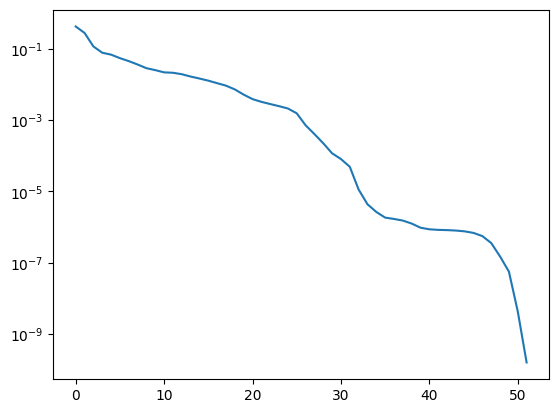

In [6]:
plt.plot(vqe_result.cost_hist-e_gs)
plt.yscale("log")

In [11]:
print(compute_expectation(vqe_result.params, ansatz, hamiltonian) - e_gs)
print(compute_expectation(vqe_result.params, ansatz, magnetization))

1.5448486934133143e-10
5.49876616620093e-05


## Sweep

In [27]:
n_qubits = 4
magnetization = ising.gen_magnetization_op(n_qubits)

ansatz = efficient_su2(
    n_qubits, entanglement="circular", reps=2
)

In [28]:
field_strs = np.linspace(0., 0.5, 11)
mags = []

for field_str in field_strs:
    hamiltonian = ising.gen_hamiltonian_op(field=field_str, coupling=1.0, n_qubits=n_qubits)

    eigenvalues, eigenvectors = np.linalg.eigh(np.array(hamiltonian))
    e_gs = min(eigenvalues)

    vqe_result = ising.run_vqe(ansatz, hamiltonian, compute_expectation)

    mags.append(compute_expectation(vqe_result.params, ansatz, magnetization))

    print("The ground state energy is:", e_gs)
    print("VQE Error:", vqe_result.energy-e_gs)
    print("Magnetization:", mags[-1])

The ground state energy is: -4.0
VQE Error: 2.1369572777985013e-12
Magnetization: -3.9999999999977414
The ground state energy is: -4.002502342280509
VQE Error: 5.372433952821609e-06
Magnetization: -0.004872172449372936
The ground state energy is: -4.010037405062516
VQE Error: 3.3300143599923615e-05
Magnetization: -3.9949657020605227
The ground state energy is: -4.022688745575003
VQE Error: 0.00013049392932451553
Magnetization: 8.411860747681299e-06
The ground state energy is: -4.040593699203862
VQE Error: 4.535515931092249e-05
Magnetization: -0.005123095382073561
The ground state energy is: -4.063940178071116
VQE Error: 0.001255381649986731
Magnetization: -3.967955850681608
The ground state energy is: -4.092961599426861
VQE Error: 0.00017380372666320199
Magnetization: -2.9554760528627266e-05
The ground state energy is: -4.12792944300034
VQE Error: 0.004501362176294599
Magnetization: 3.93544002421212
The ground state energy is: -4.1691429451087645
VQE Error: 0.007512067647102327
Magneti

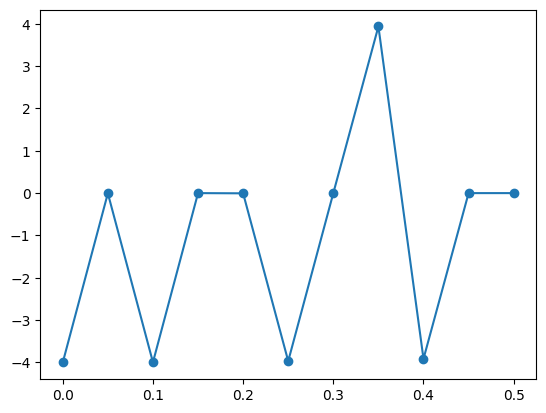

In [29]:
plt.plot(field_strs, mags, marker='o')
plt.show()